In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

df = pd.read_csv('dataset.csv', index_col="id")

/home/oscarm524/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Basic Dataset Overview

In [2]:
print(f"Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print()
print("Data Types:")
print(df.dtypes)
print()
df.head(10)

Shape: (1500, 13)
Number of rows: 1500
Number of columns: 13

Data Types:
x1         float64
x2         float64
Country     object
City        object
x4         float64
x5         float64
x6         float64
x7         float64
x8         float64
x9         float64
x10        float64
x11        float64
target     float64
dtype: object



,x1,x2,Country,City,x4,x5,x6,x7,x8,x9,x10,x11,target
id,,,,,,,,,,,,,
0,-0.175051,0.209285,Spain,Zaragoza,-0.342731,11.469364,-17.528967,-4.090882,-0.299296,4.957600,5.713463,5.180641,-31.579240
1,0.440415,-0.295561,Spain,Zaragoza,-0.369091,11.965634,-9.459683,15.313863,-0.279649,3.209983,3.873026,3.838939,-50.798957
2,0.414008,0.380512,Spain,Zaragoza,-0.457580,10.585344,8.834357,15.682925,-0.420973,3.140112,0.525711,1.805406,-42.301200
3,-0.213491,-0.217367,Spain,Albacete,-0.421154,11.306584,17.789389,2.745475,-0.279881,3.358094,5.127907,2.663848,-17.248885
4,0.281803,-0.355358,Spain,Zaragoza,-0.441993,7.023486,17.664437,-3.459430,-0.294983,3.780603,4.208882,0.977233,-5.693544
5,0.157256,-0.120902,Spain,Albacete,-0.200723,9.980374,17.670325,3.429228,-0.198266,4.767525,1.498364,4.320659,-7.512575
6,0.029477,0.034084,Spain,Albacete,-0.301085,7.442882,-7.364777,16.424374,-0.243629,4.610144,3.962442,2.499645,29.468791
7,-0.164762,-0.064293,Spain,Albacete,-0.498275,10.639232,17.339619,4.830902,-0.382881,4.448740,2.326026,5.573260,-1.353298
8,0.223320,-0.009567,Spain,Albacete,-0.205636,7.630361,-14.657058,10.448475,-0.357000,4.599758,2.134973,0.185782,16.266123


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   x1       1500 non-null   float64
 1   x2       1500 non-null   float64
 2   Country  1500 non-null   object 
 3   City     1500 non-null   object 
 4   x4       1500 non-null   float64
 5   x5       1500 non-null   float64
 6   x6       1500 non-null   float64
 7   x7       1500 non-null   float64
 8   x8       1500 non-null   float64
 9   x9       1500 non-null   float64
 10  x10      1500 non-null   float64
 11  x11      1500 non-null   float64
 12  target   1500 non-null   float64
dtypes: float64(11), object(2)
memory usage: 164.1+ KB


## 2. Missing Values Analysis

In [4]:
## Missing values count and percentage
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print(missing_df)
print(f"\nTotal cells with missing values: {df.isnull().sum().sum()}")
print(f"Columns with missing values: {(missing_count > 0).sum()}")

Missing Values Summary:
         Missing Count  Missing %
x1                   0        0.0
x2                   0        0.0
Country              0        0.0
City                 0        0.0
x4                   0        0.0
x5                   0        0.0
x6                   0        0.0
x7                   0        0.0
x8                   0        0.0
x9                   0        0.0
x10                  0        0.0
x11                  0        0.0
target               0        0.0

Total cells with missing values: 0
Columns with missing values: 0


In [5]:
## Visualize missing values
if df.isnull().sum().sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
    ax.set_title('Missing Values Heatmap', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


## 3. Descriptive Statistics for Numeric Features

In [6]:
## Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'target']

print(f"Numeric features: {feature_cols}")
print(f"Categorical features: {categorical_cols}")
print(f"Target: target")
print()

## Descriptive statistics for all numeric columns (including target)
df[numeric_cols].describe().T.round(4)

Numeric features: ['x1', 'x2', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11']
Categorical features: ['Country', 'City']
Target: target



,count,mean,std,min,25%,50%,75%,max
x1,1500.0,0.0173,0.2908,-0.4999,-0.2375,0.0344,0.2701,0.4999
x2,1500.0,0.0058,0.2893,-0.4999,-0.2399,0.0069,0.2586,0.4997
x4,1500.0,0.0017,0.3487,-0.4997,-0.3346,0.0000,0.3429,0.4998
x5,1500.0,155.8640,351.5254,7.0009,8.3482,9.8036,11.3688,999.0000
x6,1500.0,-0.2152,12.9614,-18.0000,-13.2410,-0.8542,12.9692,18.0000
x7,1500.0,-0.3741,12.4913,-17.9997,-12.4868,-0.6949,11.9795,18.0000
x8,1500.0,-0.0234,0.2866,-0.4992,-0.2770,-0.0508,0.2221,0.4991
x9,1500.0,4.9935,1.1312,3.0001,4.0230,4.9991,5.9611,6.9958
x10,1500.0,3.0255,1.7378,0.0014,1.5239,3.0325,4.5440,5.9975
x11,1500.0,3.0919,1.7380,0.0002,1.6147,3.1557,4.6394,5.9974


In [7]:
## Skewness and Kurtosis for numeric columns
skew_kurt = pd.DataFrame({
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurtosis()
}).round(4)

print("Skewness and Kurtosis:")
print(skew_kurt)
print()
print("Note: |Skewness| > 1 indicates high skew; |Kurtosis| > 3 indicates heavy tails.")

Skewness and Kurtosis:
        Skewness  Kurtosis
x1       -0.1029   -1.1777
x2       -0.0404   -1.1943
x4       -0.0027   -1.7133
x5        1.9845    1.9408
x6        0.0328   -1.5330
x7        0.0553   -1.4564
x8        0.1648   -1.2181
x9        0.0012   -1.1723
x10      -0.0287   -1.1974
x11      -0.0609   -1.2141
target   -0.0066   -0.3252

Note: |Skewness| > 1 indicates high skew; |Kurtosis| > 3 indicates heavy tails.


## 4. Target Variable Analysis

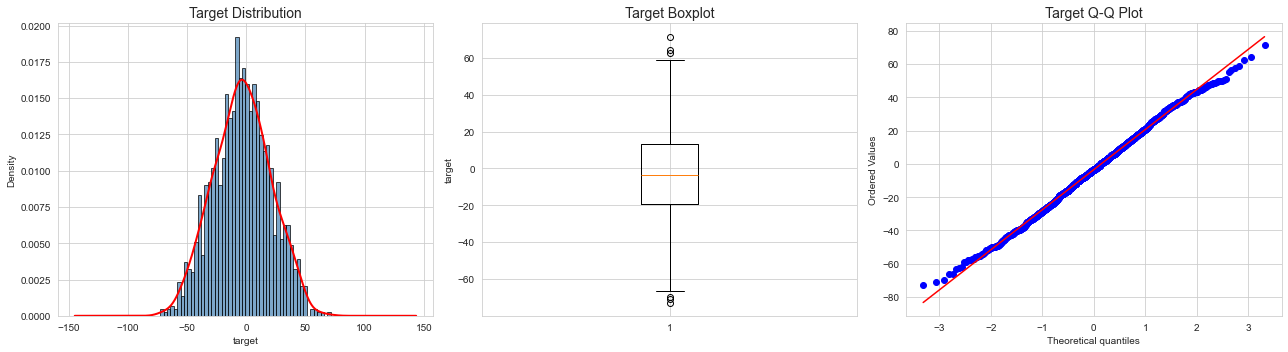

Mean: -3.4019
Median: -3.3771
Std Dev: 24.1048
Skewness: -0.0066
Kurtosis: -0.3252
Min: -72.7598
Max: 71.4442
IQR: 32.4831


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

## Histogram with KDE
axes[0].hist(df['target'], bins=50, edgecolor='black', alpha=0.7, density=True, color='steelblue')
df['target'].plot.kde(ax=axes[0], color='red', linewidth=2)
axes[0].set_title('Target Distribution', fontsize=14)
axes[0].set_xlabel('target')
axes[0].set_ylabel('Density')

## Boxplot
axes[1].boxplot(df['target'].dropna(), vert=True)
axes[1].set_title('Target Boxplot', fontsize=14)
axes[1].set_ylabel('target')

## QQ plot
stats.probplot(df['target'].dropna(), dist="norm", plot=axes[2])
axes[2].set_title('Target Q-Q Plot', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Mean: {df['target'].mean():.4f}")
print(f"Median: {df['target'].median():.4f}")
print(f"Std Dev: {df['target'].std():.4f}")
print(f"Skewness: {df['target'].skew():.4f}")
print(f"Kurtosis: {df['target'].kurtosis():.4f}")
print(f"Min: {df['target'].min():.4f}")
print(f"Max: {df['target'].max():.4f}")
print(f"IQR: {df['target'].quantile(0.75) - df['target'].quantile(0.25):.4f}")

In [9]:
## Baseline MAE: predicting the mean vs predicting the median
## For MAE, the optimal constant prediction is the median
from sklearn.metrics import mean_absolute_error

mean_pred = np.full(len(df), df['target'].mean())
median_pred = np.full(len(df), df['target'].median())

mae_mean = mean_absolute_error(df['target'], mean_pred)
mae_median = mean_absolute_error(df['target'], median_pred)

print("Baseline MAE (naive predictions):")
print(f"  Predict Mean:   MAE = {mae_mean:.4f}")
print(f"  Predict Median: MAE = {mae_median:.4f}")
print(f"\nThe median is the optimal constant predictor for MAE.")

Baseline MAE (naive predictions):
  Predict Mean:   MAE = 19.3891
  Predict Median: MAE = 19.3891

The median is the optimal constant predictor for MAE.


## 5. Numeric Feature Distributions

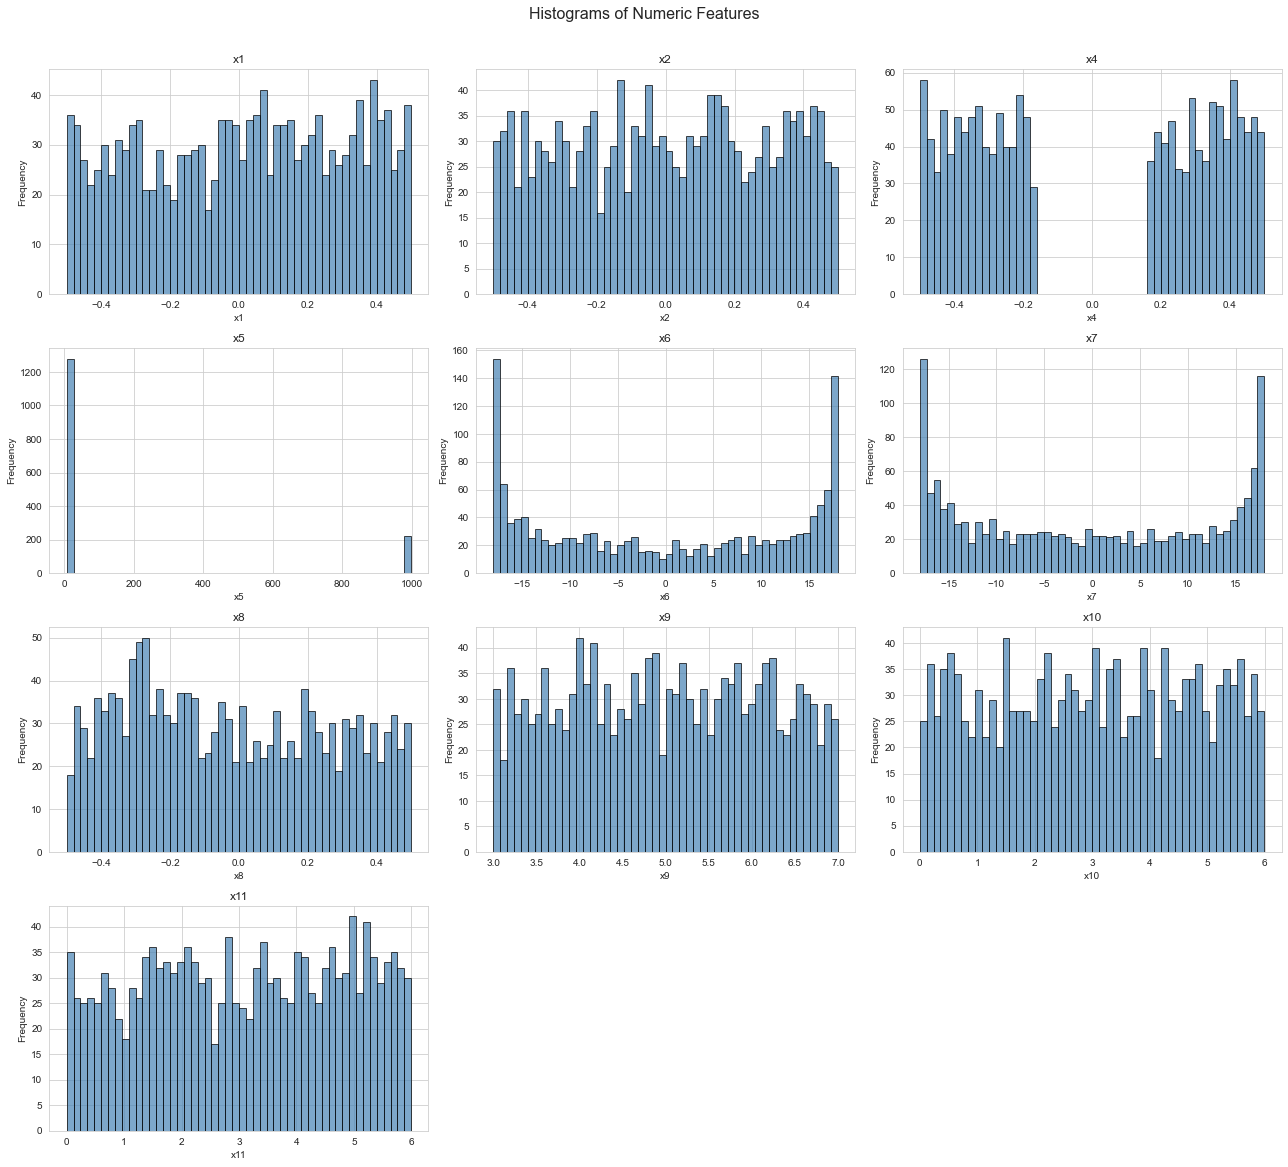

In [10]:
## Histograms for all numeric features
n_features = len(feature_cols)
n_cols_plot = 3
n_rows_plot = (n_features + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

## Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histograms of Numeric Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

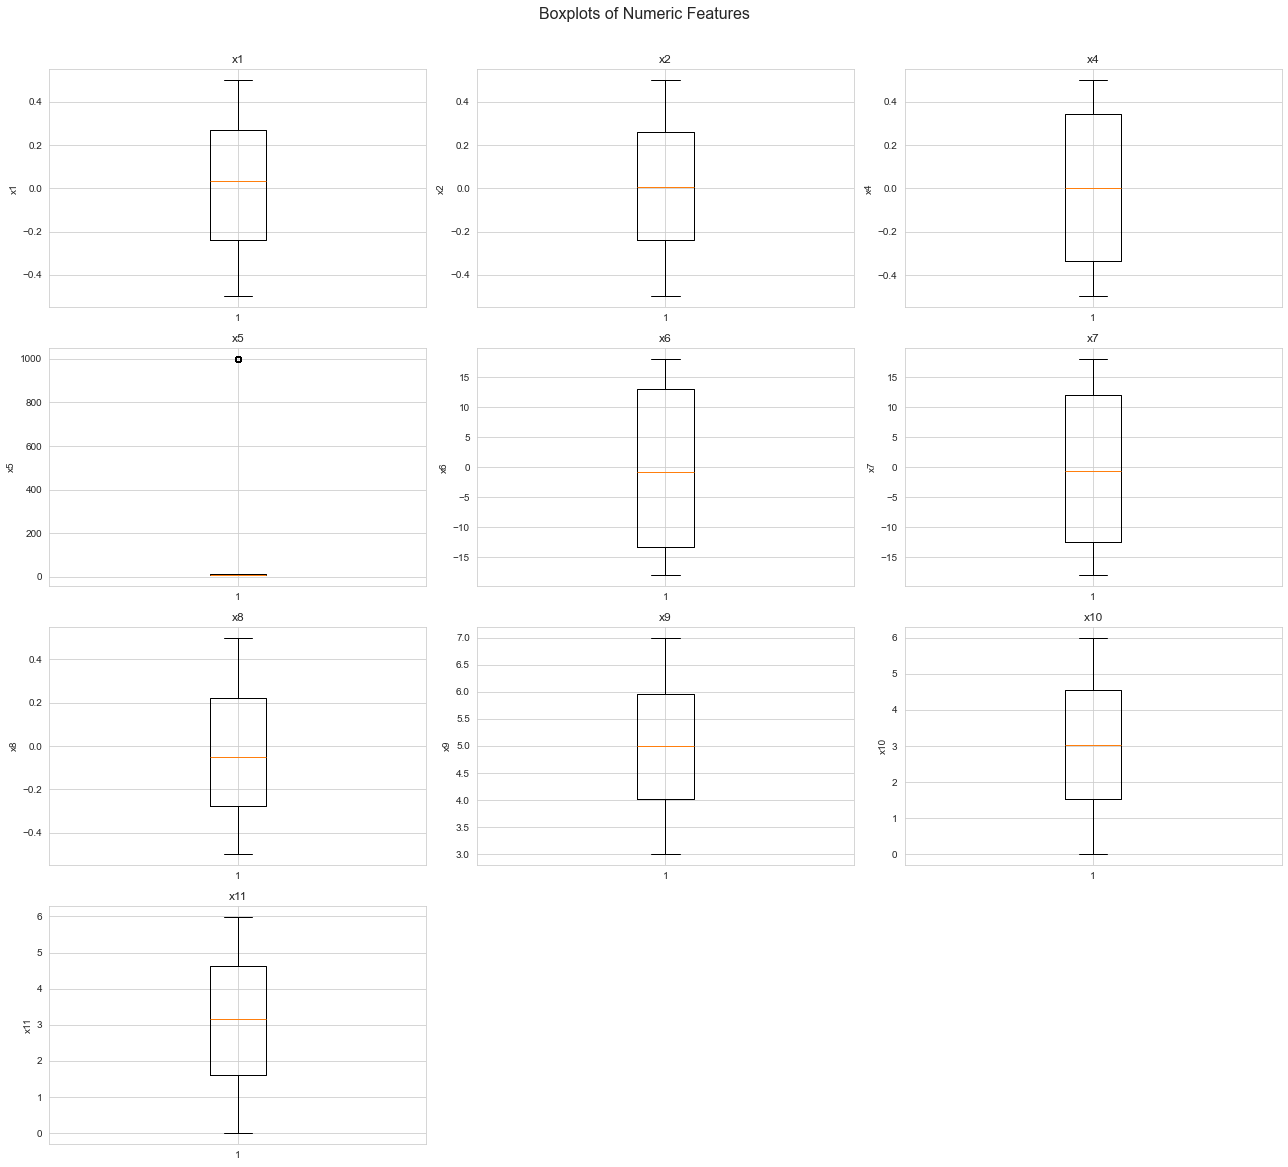

In [11]:
## Boxplots for all numeric features
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots of Numeric Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 6. Outlier Detection (IQR Method)

In [12]:
## Outlier detection using IQR method
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Lower Bound': round(lower_bound, 4),
        'Upper Bound': round(upper_bound, 4),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,x1,-0.2375,0.2701,0.5075,-0.9988,1.0314,0,0.0
1,x2,-0.2399,0.2586,0.4985,-0.9876,1.0063,0,0.0
2,x4,-0.3346,0.3429,0.6775,-1.3509,1.3592,0,0.0
3,x5,8.3482,11.3688,3.0206,3.8173,15.8997,222,14.8
4,x6,-13.2410,12.9692,26.2101,-52.5561,52.2844,0,0.0
5,x7,-12.4868,11.9795,24.4663,-49.1862,48.6789,0,0.0
6,x8,-0.2770,0.2221,0.4991,-1.0256,0.9707,0,0.0
7,x9,4.0230,5.9611,1.9381,1.1158,8.8683,0,0.0
8,x10,1.5239,4.5440,3.0200,-3.0061,9.0740,0,0.0
9,x11,1.6147,4.6394,3.0247,-2.9223,9.1764,0,0.0


## 7. Categorical Features Analysis

In [13]:
## Cardinality and value counts for categorical features
for col in categorical_cols:
    print(f"--- {col} ---")
    print(f"Unique values: {df[col].nunique()}")
    print(f"Value counts:")
    print(df[col].value_counts())
    print()

--- Country ---
Unique values: 1
Value counts:
Country
Spain    1500
Name: count, dtype: int64

--- City ---
Unique values: 2
Value counts:
City
Zaragoza    769
Albacete    731
Name: count, dtype: int64



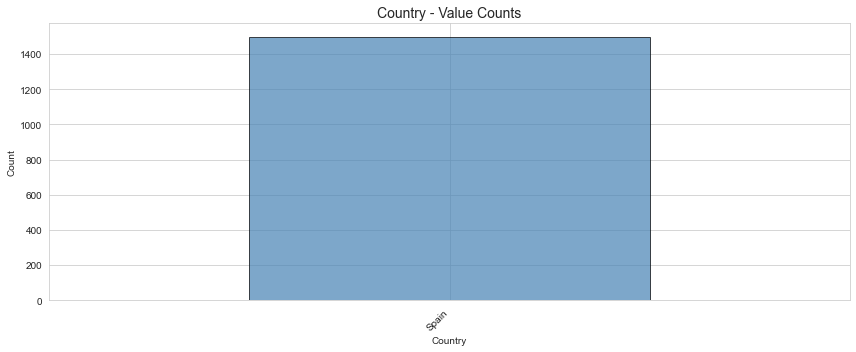

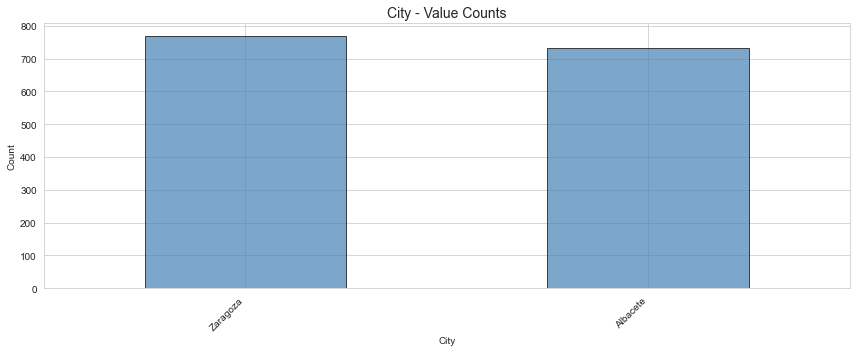

In [14]:
## Bar plots for categorical features
for col in categorical_cols:
    vc = df[col].value_counts()
    
    ## If high cardinality, show top 20
    if len(vc) > 20:
        vc = vc.head(20)
        title_suffix = " (Top 20)"
    else:
        title_suffix = ""
    
    fig, ax = plt.subplots(figsize=(12, 5))
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} - Value Counts{title_suffix}', fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

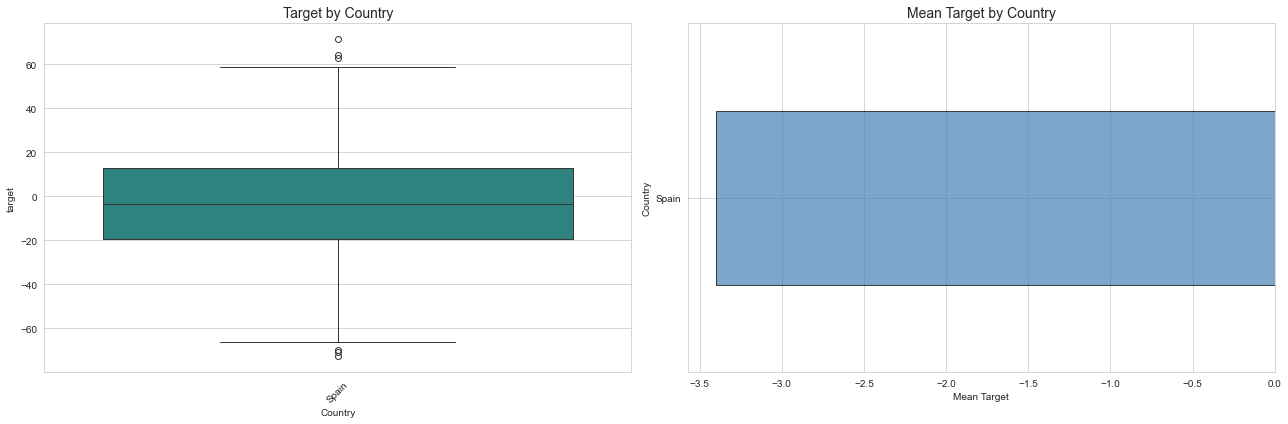


Target statistics by Country:
         count    mean  median      std
Country                                
Spain     1500 -3.4019 -3.3771  24.1048



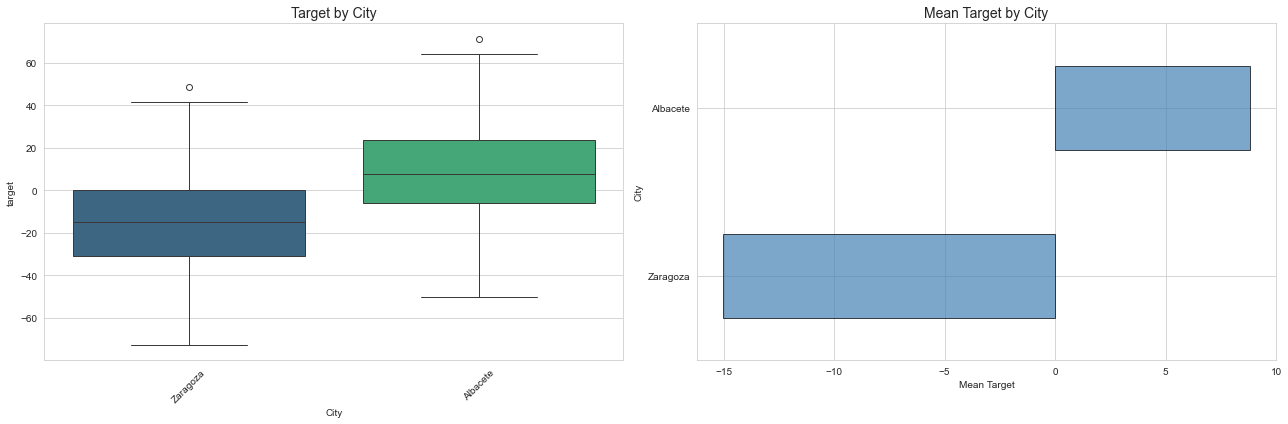


Target statistics by City:
          count     mean   median      std
City                                      
Zaragoza    769 -15.0177 -14.9879  21.3379
Albacete    731   8.8177   7.9187  20.5537



In [15]:
## Target distribution by categorical features
for col in categorical_cols:
    top_categories = df[col].value_counts().head(15).index
    subset = df[df[col].isin(top_categories)]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    ## Boxplot
    order = subset.groupby(col)['target'].median().sort_values().index
    sns.boxplot(data=subset, x=col, y='target', order=order, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Target by {col}', fontsize=14)
    axes[0].tick_params(axis='x', rotation=45)
    
    ## Mean target by category
    mean_target = subset.groupby(col)['target'].agg(['mean', 'median', 'std']).sort_values('mean')
    mean_target['mean'].plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].set_title(f'Mean Target by {col}', fontsize=14)
    axes[1].set_xlabel('Mean Target')
    
    plt.tight_layout()
    plt.show()
    
    ## Print summary stats per category
    print(f"\nTarget statistics by {col}:")
    print(subset.groupby(col)['target'].agg(['count', 'mean', 'median', 'std']).sort_values('mean').round(4))
    print()

In [16]:
## ANOVA test: Is the target significantly different across categories?
from scipy.stats import f_oneway

for col in categorical_cols:
    groups = [group['target'].values for name, group in df.groupby(col)]
    if len(groups) >= 2:
        f_stat, p_value = f_oneway(*groups)
        print(f"ANOVA for {col}: F-statistic = {f_stat:.4f}, p-value = {p_value:.6f}")
        if p_value < 0.05:
            print(f"  → Statistically significant (p < 0.05): {col} has a significant effect on target.")
        else:
            print(f"  → Not statistically significant (p >= 0.05): {col} may NOT have a significant effect on target.")
        print()

ANOVA for City: F-statistic = 484.6619, p-value = 0.000000
  → Statistically significant (p < 0.05): City has a significant effect on target.



## 8. Correlation Analysis

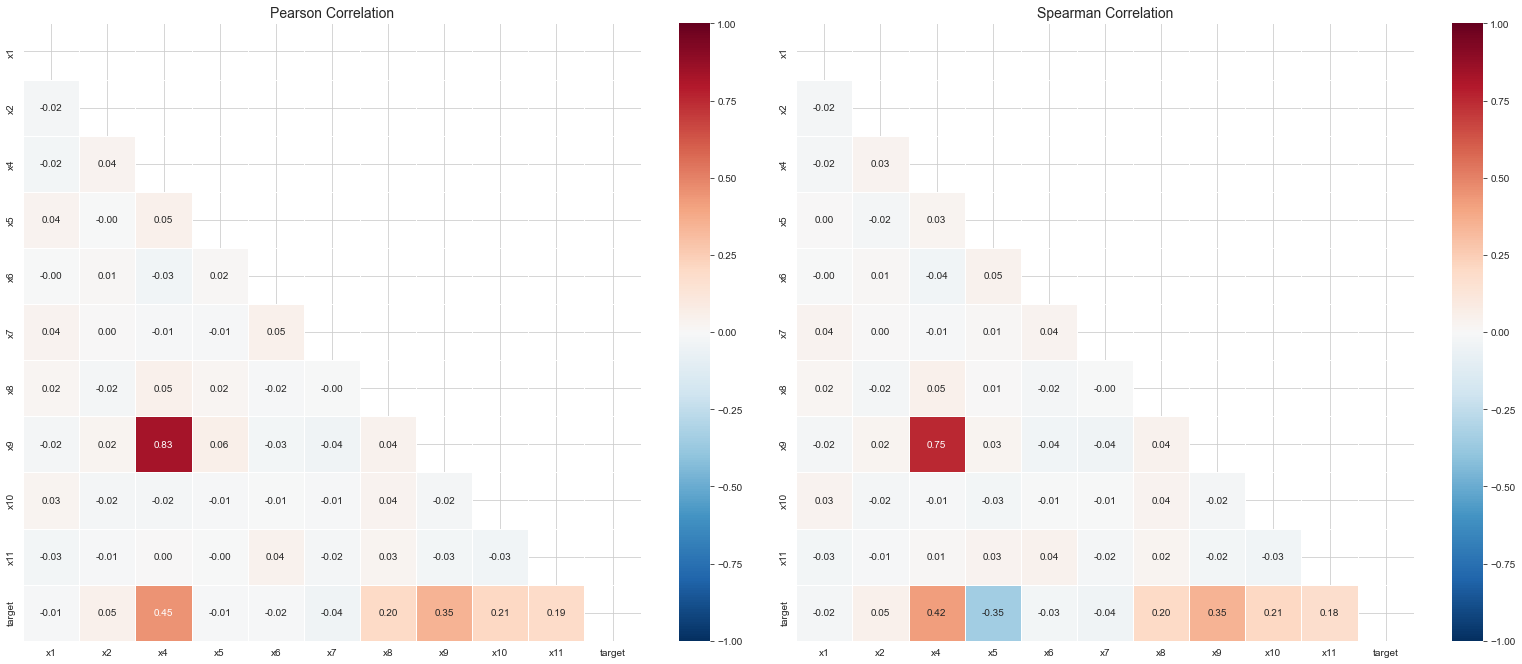

In [17]:
## Pearson Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

pearson_corr = df[numeric_cols].corr(method='pearson')
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation', fontsize=14)

## Spearman Correlation Heatmap
spearman_corr = df[numeric_cols].corr(method='spearman')
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Correlation', fontsize=14)

plt.tight_layout()
plt.show()

Correlation with Target (sorted by |Pearson|):
     Pearson (abs)  |Pearson|  Spearman (abs)  |Spearman|
x4          0.4473     0.4473          0.4201      0.4201
x9          0.3474     0.3474          0.3497      0.3497
x10         0.2089     0.2089          0.2058      0.2058
x8          0.2017     0.2017          0.1954      0.1954
x11         0.1880     0.1880          0.1752      0.1752
x2          0.0486     0.0486          0.0475      0.0475
x7         -0.0443     0.0443         -0.0411      0.0411
x6         -0.0151     0.0151         -0.0288      0.0288
x1         -0.0137     0.0137         -0.0233      0.0233
x5         -0.0110     0.0110         -0.3476      0.3476


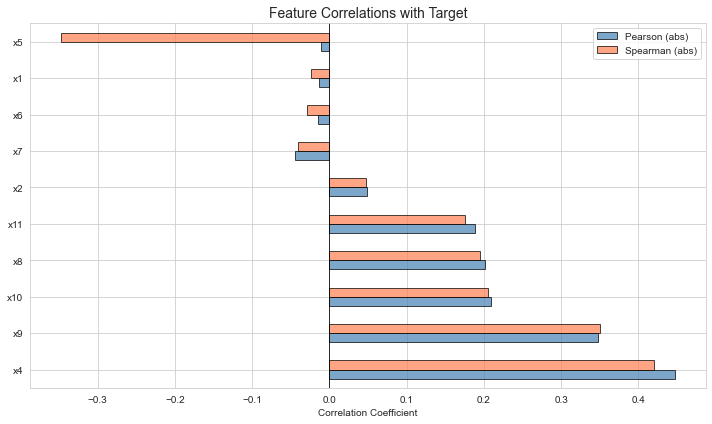

In [18]:
## Correlation with target - sorted by absolute value
target_pearson = pearson_corr['target'].drop('target').abs().sort_values(ascending=False)
target_spearman = spearman_corr['target'].drop('target').abs().sort_values(ascending=False)

corr_comparison = pd.DataFrame({
    'Pearson (abs)': pearson_corr['target'].drop('target'),
    '|Pearson|': target_pearson,
    'Spearman (abs)': spearman_corr['target'].drop('target'),
    '|Spearman|': target_spearman.reindex(target_pearson.index)
}).sort_values('|Pearson|', ascending=False)

print("Correlation with Target (sorted by |Pearson|):")
print(corr_comparison.round(4))

## Visualize
fig, ax = plt.subplots(figsize=(10, 6))
corr_comparison[['Pearson (abs)', 'Spearman (abs)']].plot(kind='barh', ax=ax, color=['steelblue', 'coral'], edgecolor='black', alpha=0.7)
ax.set_title('Feature Correlations with Target', fontsize=14)
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [19]:
## Check for high multicollinearity among features
feature_corr = df[feature_cols].corr(method='pearson')

## Find pairs with |correlation| > 0.7
high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        corr_val = feature_corr.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'Feature 1': feature_cols[i],
                'Feature 2': feature_cols[j],
                'Pearson Corr': round(corr_val, 4)
            })

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.7):")
    print(pd.DataFrame(high_corr_pairs))
else:
    print("No highly correlated feature pairs found (|r| > 0.7).")

Highly correlated feature pairs (|r| > 0.7):
  Feature 1 Feature 2  Pearson Corr
0        x4        x9        0.8315


## 9. Scatter Plots: Numeric Features vs Target

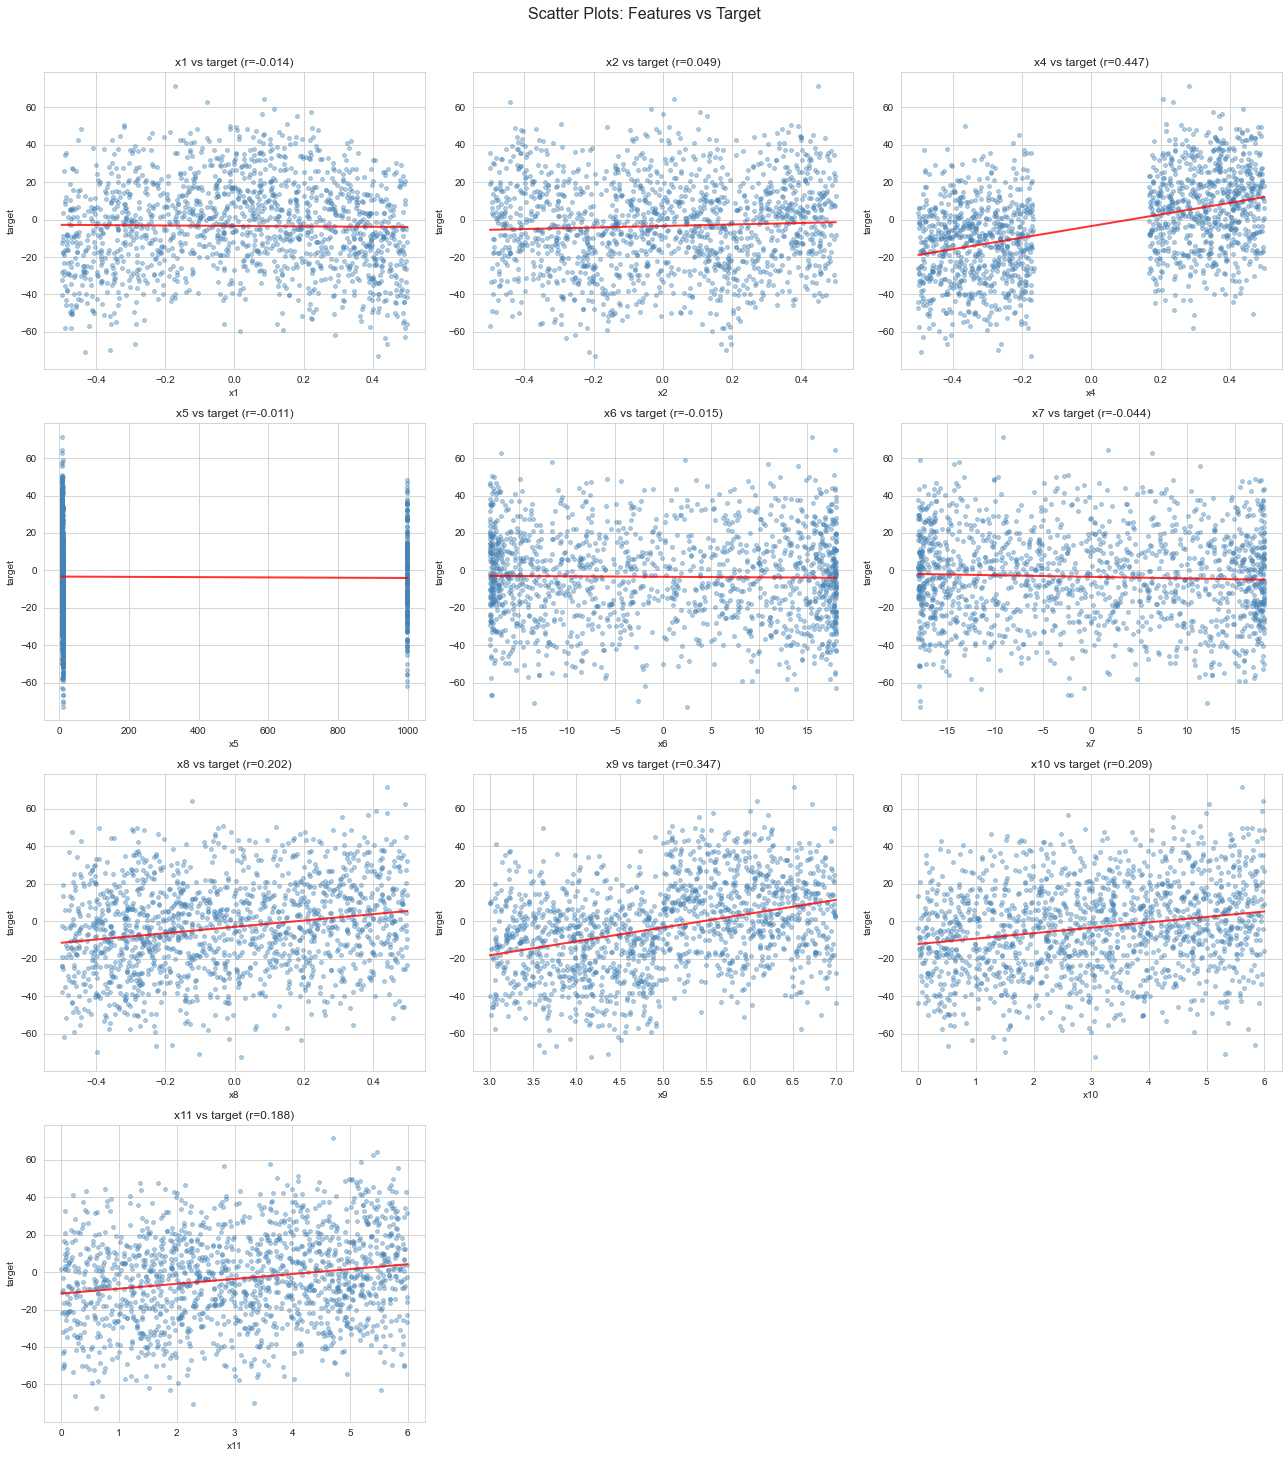

In [20]:
## Scatter plots: each numeric feature vs target
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df['target'], alpha=0.4, s=15, color='steelblue')
    
    ## Add trend line
    z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'target'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=2, alpha=0.8)
    
    r = df[col].corr(df['target'])
    axes[i].set_title(f'{col} vs target (r={r:.3f})', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('target')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Scatter Plots: Features vs Target', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 10. Feature Interactions (Top Correlated Pairs with Target)

Top 4 features by |Pearson| with target: ['x4', 'x9', 'x10', 'x8']


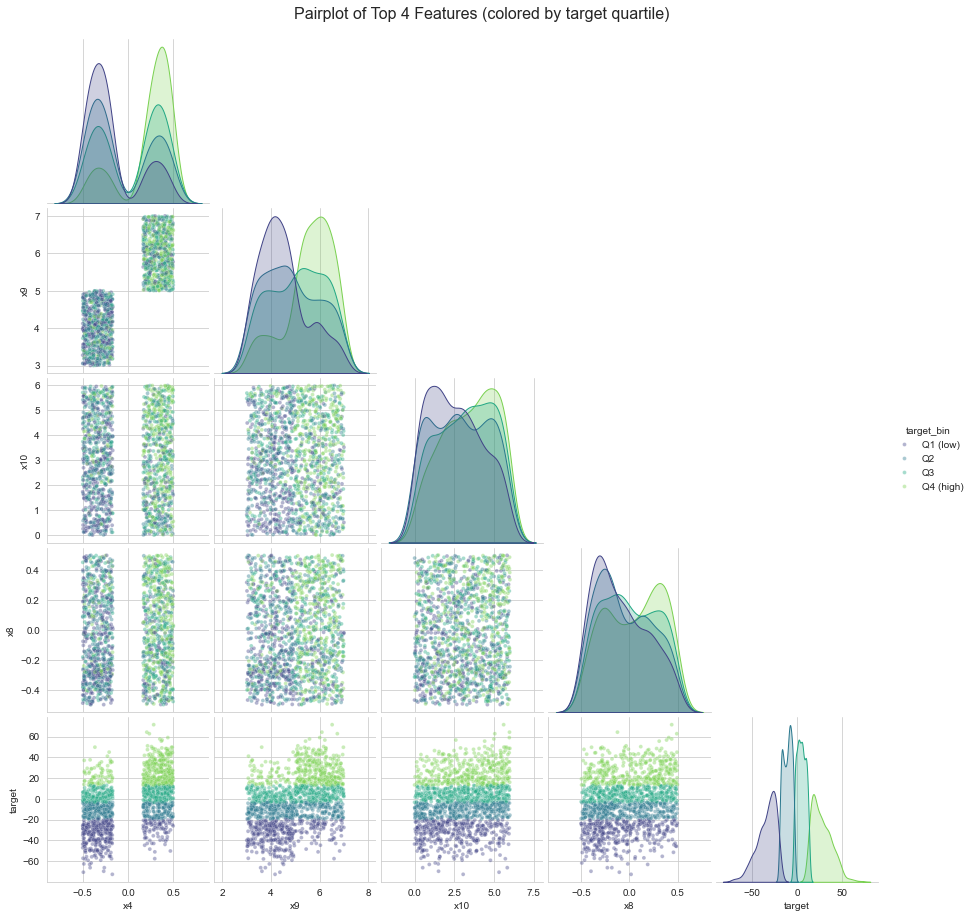

In [21]:
## Select top 4 features most correlated with target
top_features = target_pearson.head(4).index.tolist()
print(f"Top 4 features by |Pearson| with target: {top_features}")

## Pairplot colored by target (binned)
plot_df = df[top_features + ['target']].copy()
plot_df['target_bin'] = pd.qcut(df['target'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

g = sns.pairplot(plot_df, hue='target_bin', palette='viridis', 
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde',
                 corner=True)
g.figure.suptitle('Pairplot of Top 4 Features (colored by target quartile)', y=1.02, fontsize=16)
plt.show()

## 11. Non-Linear Relationship Detection (Pearson vs Spearman Gap)

In [22]:
## Compare Pearson vs Spearman to detect non-linear relationships
## A large gap (|Spearman| >> |Pearson|) suggests a monotonic but non-linear relationship
nonlinear_df = pd.DataFrame({
    '|Pearson|': pearson_corr['target'].drop('target').abs(),
    '|Spearman|': spearman_corr['target'].drop('target').abs(),
}).round(4)
nonlinear_df['Gap (|Spearman| - |Pearson|)'] = (nonlinear_df['|Spearman|'] - nonlinear_df['|Pearson|']).round(4)
nonlinear_df = nonlinear_df.sort_values('Gap (|Spearman| - |Pearson|)', ascending=False)

print("Non-linear relationship indicators (large gap → potential non-linearity):")
print(nonlinear_df)
print()
print("Features where |Spearman| >> |Pearson| may benefit from non-linear transforms.")

Non-linear relationship indicators (large gap → potential non-linearity):
     |Pearson|  |Spearman|  Gap (|Spearman| - |Pearson|)
x5      0.0110      0.3476                        0.3366
x6      0.0151      0.0288                        0.0137
x1      0.0137      0.0233                        0.0096
x9      0.3474      0.3497                        0.0023
x2      0.0486      0.0475                       -0.0011
x10     0.2089      0.2058                       -0.0031
x7      0.0443      0.0411                       -0.0032
x8      0.2017      0.1954                       -0.0063
x11     0.1880      0.1752                       -0.0128
x4      0.4473      0.4201                       -0.0272

Features where |Spearman| >> |Pearson| may benefit from non-linear transforms.


## 12. Duplicate Rows & Constant Features Check

In [23]:
## Check for duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates} ({n_duplicates / len(df) * 100:.2f}%)")

## Check for constant or near-constant features
print("\nUnique value counts per feature:")
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"  {col}: {n_unique} unique values", end="")
    if n_unique == 1:
        print(" ⚠️ CONSTANT - consider dropping")
    elif n_unique <= 5 and col in feature_cols:
        print(" ⚠️ Very low cardinality for numeric feature")
    else:
        print()

Duplicate rows: 0 (0.00%)

Unique value counts per feature:
  x1: 1500 unique values
  x2: 1500 unique values
  Country: 1 unique values ⚠️ CONSTANT - consider dropping
  City: 2 unique values
  x4: 1500 unique values
  x5: 1279 unique values
  x6: 1500 unique values
  x7: 1500 unique values
  x8: 1500 unique values
  x9: 1500 unique values
  x10: 1500 unique values
  x11: 1500 unique values
  target: 1500 unique values


## 13. Mutual Information Scores (Non-Linear Importance)

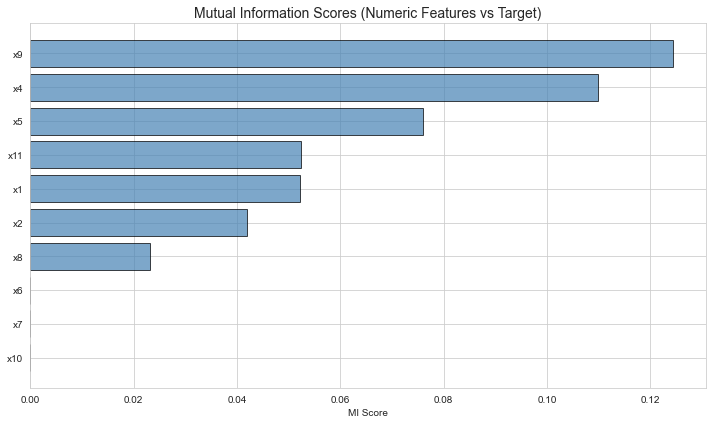

Mutual Information Scores (higher = more informative):
Feature  MI Score
     x9  0.124483
     x4  0.109930
     x5  0.076085
    x11  0.052408
     x1  0.052110
     x2  0.041858
     x8  0.023107
     x6  0.000000
     x7  0.000000
    x10  0.000000


In [24]:
from sklearn.feature_selection import mutual_info_regression

## Compute MI scores for numeric features
X_numeric = df[feature_cols].dropna()
y_numeric = df.loc[X_numeric.index, 'target']

mi_scores = mutual_info_regression(X_numeric, y_numeric, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI Score': mi_scores}).sort_values('MI Score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Mutual Information Scores (Numeric Features vs Target)', fontsize=14)
ax.set_xlabel('MI Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Mutual Information Scores (higher = more informative):")
print(mi_df.to_string(index=False))

## 14. Country–City Relationship

In [25]:
## Explore Country-City hierarchy
print(f"Number of unique Countries: {df['Country'].nunique()}")
print(f"Number of unique Cities: {df['City'].nunique()}")

## Cities per country
cities_per_country = df.groupby('Country')['City'].nunique().sort_values(ascending=False)
print(f"\nCities per Country:")
print(cities_per_country)

## Check if City uniquely determines Country (i.e., no city belongs to multiple countries)
city_country = df.groupby('City')['Country'].nunique()
ambiguous_cities = city_country[city_country > 1]
if len(ambiguous_cities) > 0:
    print(f"\n⚠️ Cities belonging to multiple countries: {len(ambiguous_cities)}")
    print(ambiguous_cities)
else:
    print(f"\n✅ Each City belongs to exactly one Country (City is a finer-grained version of Country).")

Number of unique Countries: 1
Number of unique Cities: 2

Cities per Country:
Country
Spain    2
Name: City, dtype: int64

✅ Each City belongs to exactly one Country (City is a finer-grained version of Country).


## 15. Train vs Test Set Comparison

In [26]:
## Load test set and compare distributions
test_df = pd.read_csv('test.csv', index_col='id')
print(f"Train shape: {df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nTest columns: {test_df.columns.tolist()}")

## Check for new/missing categories in test
for col in categorical_cols:
    train_cats = set(df[col].unique())
    test_cats = set(test_df[col].unique())
    only_train = train_cats - test_cats
    only_test = test_cats - train_cats
    print(f"\n--- {col} ---")
    print(f"  Train unique: {len(train_cats)}, Test unique: {len(test_cats)}")
    if only_train:
        print(f"  ⚠️ Categories only in train: {only_train}")
    if only_test:
        print(f"  ⚠️ Categories only in test: {only_test}")
    if not only_train and not only_test:
        print(f"  ✅ Same categories in train and test")

Train shape: (1500, 13)
Test shape:  (1500, 12)

Test columns: ['x1', 'x2', 'Country', 'City', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11']

--- Country ---
  Train unique: 1, Test unique: 1
  ✅ Same categories in train and test

--- City ---
  Train unique: 2, Test unique: 2
  ✅ Same categories in train and test


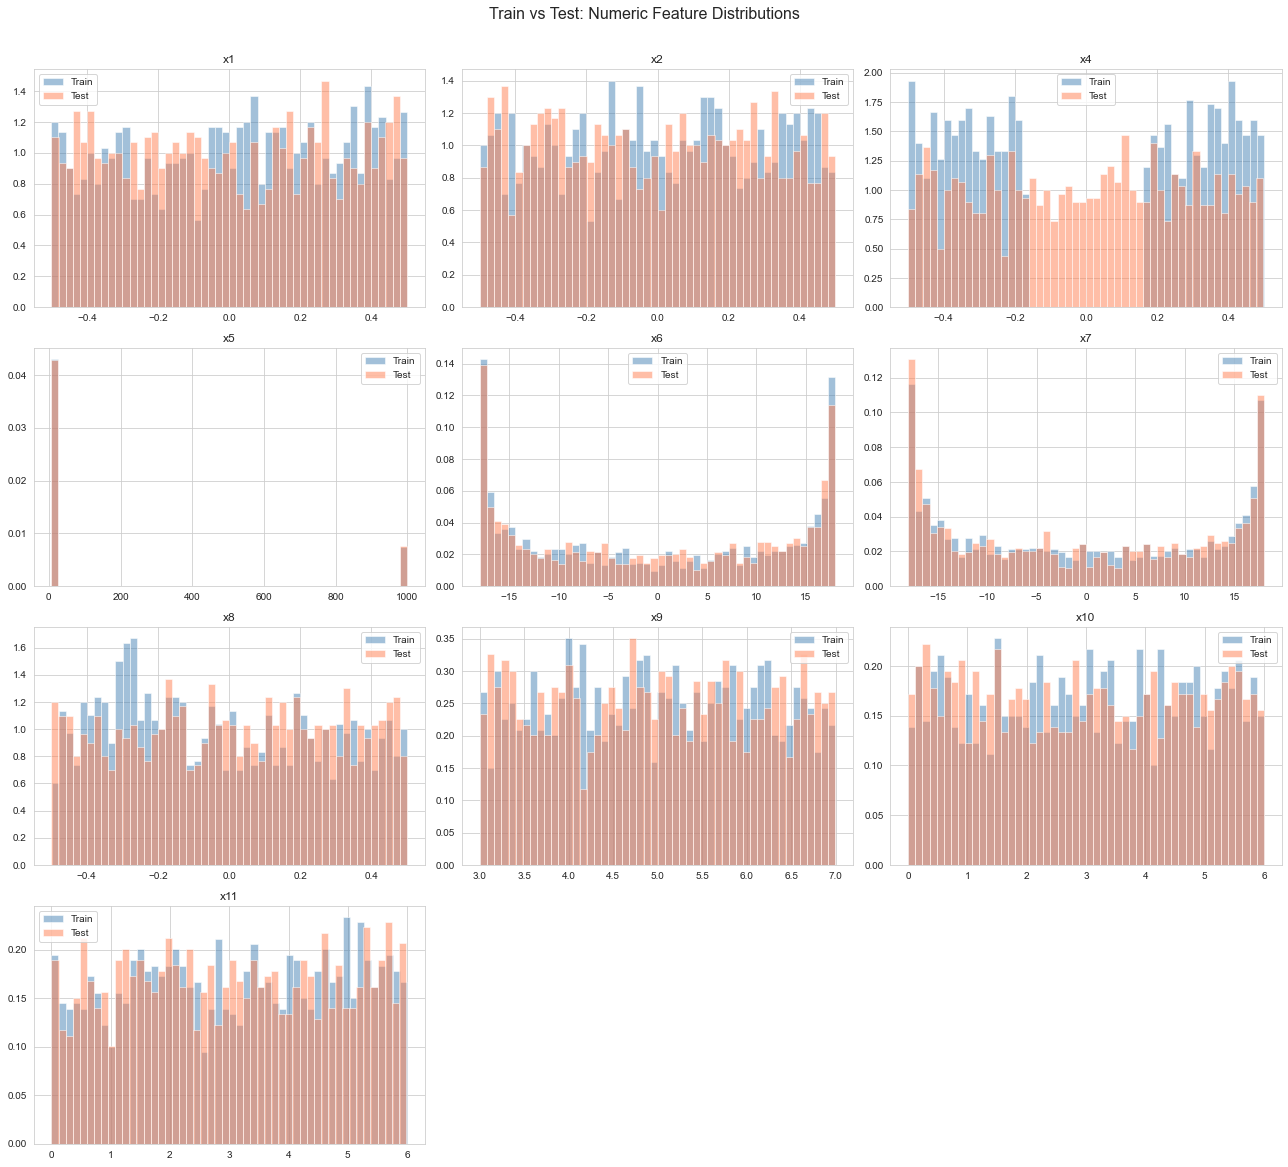

Kolmogorov-Smirnov Test (Train vs Test):
(p < 0.05 → statistically significant distribution shift)
Feature  KS Statistic  p-value
     x4        0.1747 0.000000
     x8        0.0653 0.003306
     x1        0.0573 0.014428
     x5        0.0507 0.042515
     x2        0.0380 0.228973
    x10        0.0340 0.351301
     x9        0.0280 0.599116
     x7        0.0280 0.599116
     x6        0.0260 0.691289
    x11        0.0233 0.808997


In [27]:
## Compare numeric feature distributions: Train vs Test
test_numeric_cols = [c for c in feature_cols if c in test_df.columns]

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

ks_results = []
for i, col in enumerate(test_numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, alpha=0.5, label='Train', color='steelblue', density=True)
    axes[i].hist(test_df[col].dropna(), bins=50, alpha=0.5, label='Test', color='coral', density=True)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].legend()
    
    ## KS test for distribution shift
    ks_stat, ks_p = stats.ks_2samp(df[col].dropna(), test_df[col].dropna())
    ks_results.append({'Feature': col, 'KS Statistic': round(ks_stat, 4), 'p-value': round(ks_p, 6)})

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Train vs Test: Numeric Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## KS test results
ks_df = pd.DataFrame(ks_results).sort_values('KS Statistic', ascending=False)
print("Kolmogorov-Smirnov Test (Train vs Test):")
print("(p < 0.05 → statistically significant distribution shift)")
print(ks_df.to_string(index=False))

In [28]:
## Missing values in test set
test_missing = test_df.isnull().sum()
test_missing_pct = (test_df.isnull().sum() / len(test_df) * 100).round(2)

test_missing_df = pd.DataFrame({
    'Train Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Test Missing %': test_missing_pct
})

print("Missing Values Comparison (Train vs Test):")
print(test_missing_df)

Missing Values Comparison (Train vs Test):
         Train Missing %  Test Missing %
City                 0.0             0.0
Country              0.0             0.0
target               0.0             NaN
x1                   0.0             0.0
x10                  0.0             0.0
x11                  0.0             0.0
x2                   0.0             0.0
x4                   0.0             0.0
x5                   0.0             0.0
x6                   0.0             0.0
x7                   0.0             0.0
x8                   0.0             0.0
x9                   0.0             0.0


---
## 16. Executive Summary

In [29]:
## =========================================================================
##  AUTOMATED EXECUTIVE SUMMARY
## =========================================================================

summary_lines = []
summary_lines.append("=" * 80)
summary_lines.append("EXECUTIVE SUMMARY – Data Exploration")
summary_lines.append("=" * 80)

## Dataset size
summary_lines.append(f"\n📊 DATASET SIZE")
summary_lines.append(f"   • Training set: {df.shape[0]} rows × {df.shape[1]} columns")
summary_lines.append(f"   • Test set:     {test_df.shape[0]} rows × {test_df.shape[1]} columns")
summary_lines.append(f"   • Numeric features:     {len(feature_cols)} ({', '.join(feature_cols)})")
summary_lines.append(f"   • Categorical features:  {len(categorical_cols)} ({', '.join(categorical_cols)})")

## Missing values
total_missing = df.isnull().sum().sum()
summary_lines.append(f"\n🔍 MISSING VALUES")
if total_missing == 0:
    summary_lines.append(f"   • No missing values in the training set.")
else:
    cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
    summary_lines.append(f"   • {len(cols_with_missing)} column(s) with missing values:")
    for idx, row in cols_with_missing.iterrows():
        summary_lines.append(f"     - {idx}: {int(row['Missing Count'])} ({row['Missing %']}%)")

test_total_missing = test_df.isnull().sum().sum()
if test_total_missing == 0:
    summary_lines.append(f"   • No missing values in the test set.")
else:
    summary_lines.append(f"   • Test set has {test_total_missing} total missing values.")

## Target variable
summary_lines.append(f"\n🎯 TARGET VARIABLE")
summary_lines.append(f"   • Mean: {df['target'].mean():.4f}, Median: {df['target'].median():.4f}")
summary_lines.append(f"   • Std Dev: {df['target'].std():.4f}")
summary_lines.append(f"   • Range: [{df['target'].min():.4f}, {df['target'].max():.4f}]")
summary_lines.append(f"   • Skewness: {df['target'].skew():.4f}, Kurtosis: {df['target'].kurtosis():.4f}")
summary_lines.append(f"   • Baseline MAE (predict median): {mae_median:.4f}")
summary_lines.append(f"   • Baseline MAE (predict mean):   {mae_mean:.4f}")

## Correlations
summary_lines.append(f"\n📈 TOP FEATURES BY |PEARSON CORRELATION| WITH TARGET")
for feat in target_pearson.head(5).index:
    p_val = pearson_corr['target'][feat]
    s_val = spearman_corr['target'][feat]
    summary_lines.append(f"   • {feat}: Pearson={p_val:.4f}, Spearman={s_val:.4f}")

## Multicollinearity
summary_lines.append(f"\n🔗 MULTICOLLINEARITY")
if high_corr_pairs:
    summary_lines.append(f"   • {len(high_corr_pairs)} pair(s) with |r| > 0.7:")
    for pair in high_corr_pairs:
        summary_lines.append(f"     - {pair['Feature 1']} & {pair['Feature 2']}: r = {pair['Pearson Corr']}")
else:
    summary_lines.append(f"   • No highly correlated feature pairs (|r| > 0.7).")

## Categorical features
summary_lines.append(f"\n🏷️ CATEGORICAL FEATURES")
for col in categorical_cols:
    summary_lines.append(f"   • {col}: {df[col].nunique()} unique values")

## Outliers
total_outlier_features = outlier_df[outlier_df['Outlier Count'] > 0]
summary_lines.append(f"\n⚠️ OUTLIERS (IQR Method)")
summary_lines.append(f"   • {len(total_outlier_features)} feature(s) have outliers:")
for _, row in total_outlier_features.iterrows():
    summary_lines.append(f"     - {row['Feature']}: {int(row['Outlier Count'])} outliers ({row['Outlier %']}%)")

## Train vs Test
summary_lines.append(f"\n🔄 TRAIN VS TEST DISTRIBUTION")
significant_shifts = ks_df[ks_df['p-value'] < 0.05]
if len(significant_shifts) > 0:
    summary_lines.append(f"   • {len(significant_shifts)} feature(s) show significant distribution shift (KS test, p < 0.05):")
    for _, row in significant_shifts.iterrows():
        summary_lines.append(f"     - {row['Feature']}: KS={row['KS Statistic']}, p={row['p-value']}")
else:
    summary_lines.append(f"   • No significant distribution shift detected between train and test.")

## Duplicates
summary_lines.append(f"\n📋 DUPLICATES")
summary_lines.append(f"   • Duplicate rows: {n_duplicates}")

## Recommendations
summary_lines.append(f"\n💡 RECOMMENDATIONS FOR MODELING")
summary_lines.append(f"   1. Metric: MAE — the median is the optimal constant predictor (baseline MAE ≈ {mae_median:.2f}).")
summary_lines.append(f"   2. Use tree-based models (XGBoost, LightGBM, CatBoost) that natively handle categoricals and are robust to outliers.")
summary_lines.append(f"   3. Consider MAE-specific loss functions (e.g., 'mae' or 'quantile' with alpha=0.5) instead of MSE.")
if high_corr_pairs:
    summary_lines.append(f"   4. Watch for multicollinearity among {len(high_corr_pairs)} correlated feature pair(s) if using linear models.")
if len(significant_shifts) > 0:
    summary_lines.append(f"   5. Monitor distribution-shifted features — may impact generalization.")
summary_lines.append(f"   6. Explore feature engineering: interactions among top features and categorical encodings.")

summary_lines.append(f"\n" + "=" * 80)

print("\n".join(summary_lines))

EXECUTIVE SUMMARY – Data Exploration

📊 DATASET SIZE
   • Training set: 1500 rows × 13 columns
   • Test set:     1500 rows × 12 columns
   • Numeric features:     10 (x1, x2, x4, x5, x6, x7, x8, x9, x10, x11)
   • Categorical features:  2 (Country, City)

🔍 MISSING VALUES
   • No missing values in the training set.
   • No missing values in the test set.

🎯 TARGET VARIABLE
   • Mean: -3.4019, Median: -3.3771
   • Std Dev: 24.1048
   • Range: [-72.7598, 71.4442]
   • Skewness: -0.0066, Kurtosis: -0.3252
   • Baseline MAE (predict median): 19.3891
   • Baseline MAE (predict mean):   19.3891

📈 TOP FEATURES BY |PEARSON CORRELATION| WITH TARGET
   • x4: Pearson=0.4473, Spearman=0.4201
   • x9: Pearson=0.3474, Spearman=0.3497
   • x10: Pearson=0.2089, Spearman=0.2058
   • x8: Pearson=0.2017, Spearman=0.1954
   • x11: Pearson=0.1880, Spearman=0.1752

🔗 MULTICOLLINEARITY
   • 1 pair(s) with |r| > 0.7:
     - x4 & x9: r = 0.8315

🏷️ CATEGORICAL FEATURES
   • Country: 1 unique values
   • City